#Método de la Secante


--------------------------------------------------
Iniciando Secante: Inciso A
--------------------------------------------------
Iteracion 1: Raíz calculada = 2.000000 | Error = 100.000000
Iteracion 2: Raíz calculada = 1.263158 | Error = 0.583333
Iteracion 3: Raíz calculada = 1.338828 | Error = 0.056520
Iteracion 4: Raíz calculada = 1.366616 | Error = 0.020334
Iteracion 5: Raíz calculada = 1.365212 | Error = 0.001029
Iteracion 6: Raíz calculada = 1.365230 | Error = 0.000013

--> RAÍZ FINAL APROXIMADA PARA Inciso A: 1.365230


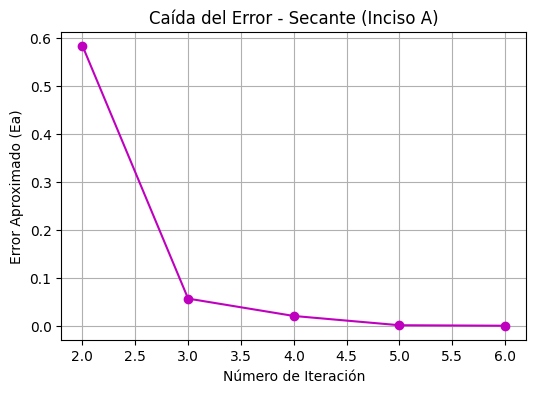


--------------------------------------------------
Iniciando Secante: Inciso B
--------------------------------------------------
Iteracion 1: Raíz calculada = 0.430825 | Error = 100.000000
Iteracion 2: Raíz calculada = 0.460328 | Error = 0.064090
Iteracion 3: Raíz calculada = 0.462183 | Error = 0.004013

--> RAÍZ FINAL APROXIMADA PARA Inciso B: 0.462183


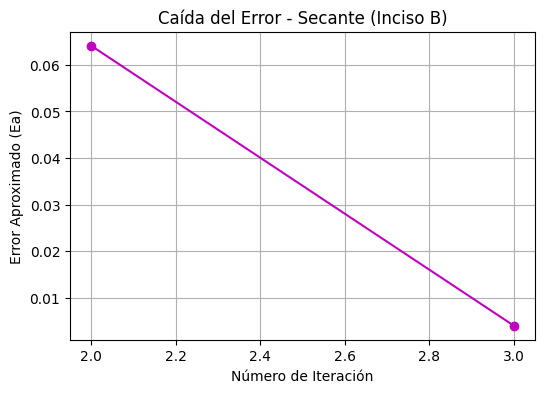


--------------------------------------------------
Iniciando Secante: Inciso C
--------------------------------------------------
Iteracion 1: Raíz calculada = -2.000000 | Error = 100.000000
Iteracion 2: Raíz calculada = 0.105263 | Error = 20.000000
Iteracion 3: Raíz calculada = -0.691910 | Error = 1.152134
Iteracion 4: Raíz calculada = -0.856473 | Error = 0.192140
Iteracion 5: Raíz calculada = -0.834788 | Error = 0.025977

--> RAÍZ FINAL APROXIMADA PARA Inciso C: -0.834788


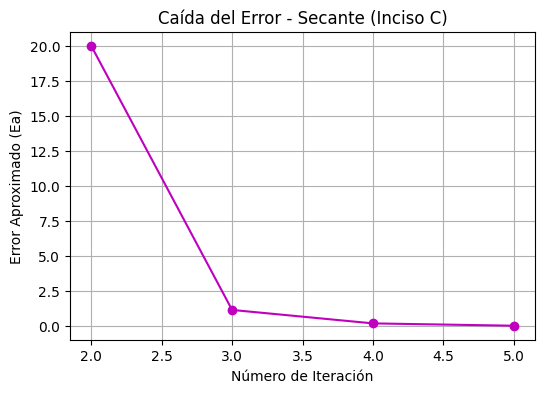


--------------------------------------------------
Iniciando Secante: Inciso D
--------------------------------------------------
Iteracion 1: Raíz calculada = 0.500000 | Error = 100.000000
Iteracion 2: Raíz calculada = 0.686275 | Error = 0.271429
Iteracion 3: Raíz calculada = 0.769025 | Error = 0.107604
Iteracion 4: Raíz calculada = 0.748059 | Error = 0.028027
Iteracion 5: Raíz calculada = 0.749342 | Error = 0.001712
Iteracion 6: Raíz calculada = 0.749368 | Error = 0.000035

--> RAÍZ FINAL APROXIMADA PARA Inciso D: 0.749368


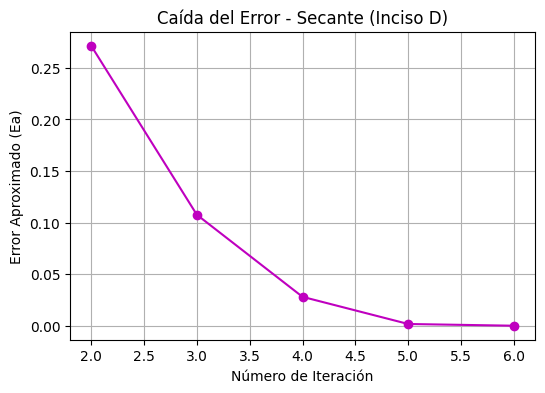

In [6]:
import math
import matplotlib.pyplot as plt

# 1.-Definimos las funciones solicitadas
def funcion_a(x):
    return (x**3) + 4*(x**2) - 10.0

def funcion_b(x):
    return math.exp(3*x) - 4.0

def funcion_c(x):
    return -0.4*(x**2) + 2.3*x + 2.2

def funcion_d(x):
    return (x**4) + 3*(x**2) - 2.0


# 2.-Método de la Secante
def ejecutar_secante(funcion_evaluar, X_Anterior, X_Actual, Error_Esperado, Nombre_Inciso):
    print(f"\n--------------------------------------------------")
    print(f"Iniciando Secante: {Nombre_Inciso}")
    print(f"--------------------------------------------------")

    Error_Actual = 100.0  # Freno forzado inicial
    Iteracion = 1

    Historial_Iteraciones = []
    Historial_Errores = []

    while Error_Actual > Error_Esperado:
        Funcion_Anterior = funcion_evaluar(X_Anterior)
        Funcion_Actual = funcion_evaluar(X_Actual)

        Denominador = Funcion_Anterior - Funcion_Actual

        if Denominador == 0:
            print("Error: División por cero")
            break

        # Fórmula de la Secante (usamos los dos puntos para la pendiente)
        Punto_Nuevo = X_Actual - (Funcion_Actual * (X_Anterior - X_Actual)) / Denominador

        # Cálculo de error
        if Iteracion > 1:
            Error_Actual = abs((Punto_Nuevo - X_Actual) / Punto_Nuevo)

        if Iteracion > 1:
            Historial_Iteraciones.append(Iteracion)
            Historial_Errores.append(Error_Actual)

        print(f"Iteracion {Iteracion}: Raíz calculada = {Punto_Nuevo:.6f} | Error = {Error_Actual:.6f}")

        # Recorremos las variables para la siguiente vuelta del loop
        X_Anterior = X_Actual
        X_Actual = Punto_Nuevo
        Iteracion = Iteracion + 1

        if Iteracion > 100:
            print("Alerta: Se superaron las 100 iteraciones.")
            break

    print(f"\n--> RAÍZ FINAL APROXIMADA PARA {Nombre_Inciso}: {Punto_Nuevo:.6f}")

    # ==========================================
    # 3.-Gráficas

    plt.figure(figsize=(6, 4))
    plt.plot(Historial_Iteraciones, Historial_Errores, marker='o', linestyle='-', color='m')
    plt.title(f"Caída del Error - Secante ({Nombre_Inciso})")
    plt.xlabel("Número de Iteración")
    plt.ylabel("Error Aproximado (Ea)")
    plt.grid(True)
    plt.show()


# 4. Ejecución en secuencia con los puntos iniciales del pizarrón

# Inciso a) x0=0, x1=1
ejecutar_secante(funcion_a, 0.0, 1.0, 0.0001, "Inciso A")

# Inciso b) x0=0, x1=1/2
ejecutar_secante(funcion_b, 0.0, 0.5, 0.01, "Inciso B")

# Inciso c) x0=0, x1=3
# OJO: Estos valores del pizarrón arrastrarán el algoritmo a la raíz negativa.
# Anota el resultado tal cual, es lo que pidió el profesor.
ejecutar_secante(funcion_c, 0.0, 3.0, 0.03, "Inciso C")

# Inciso d) x0=0, x1=1
ejecutar_secante(funcion_d, 0.0, 1.0, 0.0001, "Inciso D")